<h1> Geometric Operations and Other Mathematical Tools</h1>


Estimated time needed: **40** minutes


<h2>Objectives</h2>


In the first part of the lab, you will apply geometric transformations to an image. This allows you to perform different operations like reshape translation i.e. to shift, reshape and rotate the image. In the second part of the lab, you will learn how to apply some basic array and matrix operations to the image. 


<ul>
    <li><a href='#PT'> Geometric Operations  </a>
        <ul>
            <li>Scaling  </li>
            <li>Translation</li>
            <li>Rotation</li>   
          </ul>
        <li><a href='#PT'>  Mathematical Operations   </a>
        <ul>
            <li>Array Operations  </li>
            <li>Matix Operations n</li> 
          </ul>


</ul>


----


Download the image for the lab:


In [1]:
import urllib.request  
# Import module urllib.request dùng để gửi request HTTP (tải dữ liệu từ Internet)

urls = [
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png"
]
# Danh sách các URL chứa đường dẫn đến các file ảnh cần tải

names = ["lenna.png", "baboon.png", "barbara.png"]
# Danh sách tên file tương ứng để lưu ảnh sau khi tải về

for url, name in zip(urls, names):
    # zip() ghép từng URL với từng tên file theo cặp
    # Ví dụ: (urls[0], names[0]), (urls[1], names[1]), ...

    urllib.request.urlretrieve(url, name)
    # Gửi request tới URL để tải dữ liệu
    # Sau đó lưu dữ liệu đó thành file với tên 'name' trên máy

print("Downloaded!")
# In thông báo khi tất cả các file đã được tải xong 

Downloaded!


We will import the following:


In [2]:
import matplotlib.pyplot as plt
# Import thư viện matplotlib để vẽ biểu đồ và hiển thị ảnh

import cv2
# Import OpenCV (cv2) – thư viện xử lý ảnh và thị giác máy tính
# Dùng để đọc ảnh, xử lý ảnh, lọc, biến đổi, v.v.

import numpy as np
# Import NumPy – thư viện xử lý mảng số học
# Ảnh trong Python thường được biểu diễn dưới dạng mảng NumPy

First, let's define a helper function to plot two images side-by-side. You will not need to understand this code this moment, but this function will be used repeatedly in this tutorial to showcase the results. 


In [3]:
def plot_image(image_1, image_2, title_1="Orignal", title_2="New Image"):
    # Định nghĩa hàm dùng để hiển thị 2 ảnh song song để so sánh

    plt.figure(figsize=(10, 10)) # Tạo một cửa sổ hiển thị mới với kích thước 10x10 inch

    plt.subplot(1, 2, 1) # Chia cửa sổ thành 1 hàng, 2 cột và chọn ô thứ 1

    plt.imshow(image_1, cmap="gray")
    # Hiển thị ảnh thứ nhất
    # cmap="gray" dùng thang màu xám (phù hợp cho ảnh grayscale)

    plt.title(title_1) # Đặt tiêu đề cho ảnh thứ nhất

    plt.subplot(1, 2, 2) # Chọn ô thứ 2 trong bố cục 1 hàng, 2 cột

    plt.imshow(image_2, cmap="gray") # Hiển thị ảnh thứ hai để so sánh

    plt.title(title_2) # Đặt tiêu đề cho ảnh thứ hai

    plt.show() # Hiển thị toàn bộ figure ra màn hình

#  Geometric Transformations


 Geometric transformations allow you to perform different operations like translation i.e. to shift, reshape and rotate the image.


## Scaling 


We can resize an image using the function `resize()` from `cv2` module for this purpose.  You can specify the scaling factor or the size of the image:


Consider the following image with the corresponding intensity values:


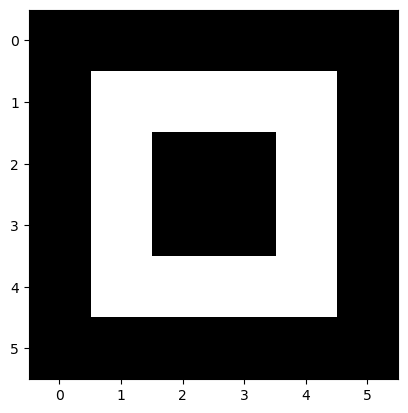

array([[  0.,   0.,   0.,   0.,   0.,   0.],
       [  0., 255., 255., 255., 255.,   0.],
       [  0., 255.,   0.,   0., 255.,   0.],
       [  0., 255.,   0.,   0., 255.,   0.],
       [  0., 255., 255., 255., 255.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.]])

In [4]:
toy_image = np.zeros((6, 6))
# Tạo một ảnh "đồ chơi" kích thước 6x6
# Ban đầu toàn bộ pixel có giá trị 0 (màu đen)

toy_image[1:5, 1:5] = 255
# Gán giá trị 255 (màu trắng) cho vùng từ hàng 1→4, cột 1→4
# Tạo một hình vuông trắng lớn ở giữa ảnh

toy_image[2:4, 2:4] = 0
# Gán lại giá trị 0 (màu đen) cho vùng từ hàng 2→3, cột 2→3
# Tạo một hình vuông đen nhỏ nằm bên trong hình vuông trắng

plt.imshow(toy_image, cmap='gray')
# Hiển thị ma trận toy_image như một ảnh xám
# 0 → đen, 255 → trắng

plt.show() # Hiển thị ảnh ra màn hình

toy_image # In ra ma trận giá trị pixel để quan sát trực tiếp cấu trúc ảnh

We can rescale along a specific axis:

- `fx`: scale factor along the horizontal axis  
- `fy`: scale factor along the vertical axis


The parameter interpolation estimates pixel values based on neighboring pixels. <code>INTER_NEAREST</code> uses the nearest pixel and <code>INTER_CUBIC</code> uses several pixels near the pixel value we would like to estimate.


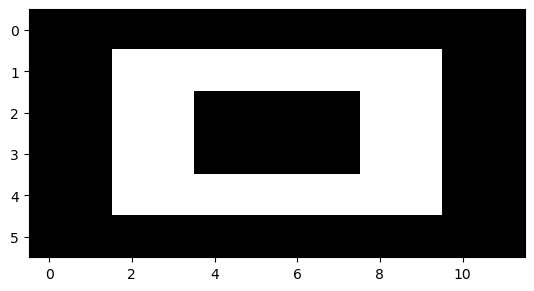

In [5]:
new_toy = cv2.resize(toy_image, None, fx=2, fy=1, interpolation=cv2.INTER_NEAREST)
# Thay đổi kích thước ảnh toy_image bằng OpenCV
# - fx=2  : phóng to ảnh theo chiều ngang gấp 2 lần
# - fy=1  : giữ nguyên chiều dọc
# - interpolation=cv2.INTER_NEAREST:
#   + Dùng phương pháp nội suy láng giềng gần nhất
#   + Mỗi pixel mới lấy giá trị pixel gần nhất
#   + Giữ biên sắc nét, không làm mờ (rất phù hợp ảnh nhị phân/toy)

plt.imshow(new_toy, cmap='gray') # Hiển thị ảnh sau khi resize dưới dạng ảnh xám

plt.show() # Hiển thị ảnh ra màn hình

Consider the following image:


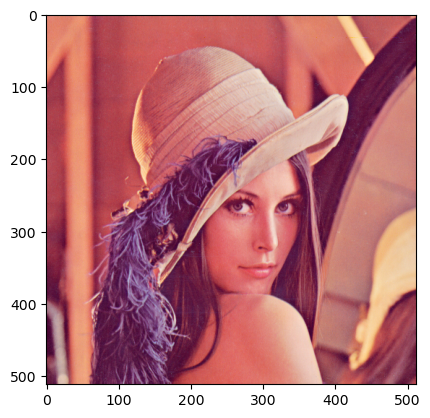

In [6]:
image = cv2.imread("lenna.png")
# Đọc ảnh từ file bằng OpenCV
# Ảnh được đọc theo thứ tự màu BGR (Blue – Green – Red), không phải RGB

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
# Chuyển không gian màu từ BGR sang RGB
# Vì matplotlib hiển thị ảnh theo chuẩn RGB
# Nếu không chuyển => ảnh sẽ bị sai màu (xanh/đỏ đảo ngược)

plt.show() # Hiển thị ảnh ra màn hình

We can scale the horizontal axis by two and leave the vertical axis as is:


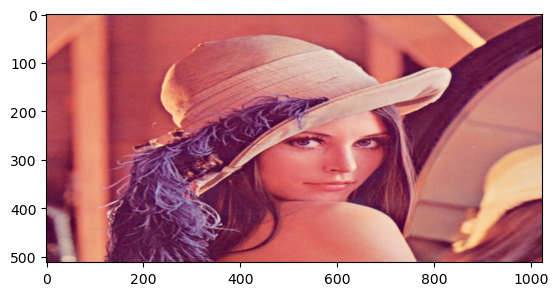

old image shape: (512, 512, 3) new image shape: (512, 1024, 3)


In [7]:
new_image = cv2.resize(image, None, fx=2, fy=1, interpolation=cv2.INTER_CUBIC)
# Thay đổi kích thước ảnh bằng OpenCV
# - fx=2 : phóng to ảnh theo chiều ngang gấp 2 lần
# - fy=1 : giữ nguyên chiều dọc
# - interpolation=cv2.INTER_CUBIC:
#   + Nội suy bậc 3 (bicubic)
#   + Tính giá trị pixel mới dựa trên nhiều pixel lân cận
#   + Ảnh mượt hơn, ít răng cưa hơn so với INTER_NEAREST và INTER_LINEAR
#   + Phù hợp khi phóng to ảnh thật

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)) # Chuyển ảnh từ BGR sang RGB để hiển thị đúng màu bằng matplotlib

plt.show() # Hiển thị ảnh ra màn hình

print("old image shape:", image.shape, "new image shape:", new_image.shape)
# In ra kích thước ảnh trước và sau khi resize
# shape = (height, width, channels)
# Có thể thấy width tăng gấp đôi, height giữ nguyên

In the same manner, we can scale the vertical axis by two:


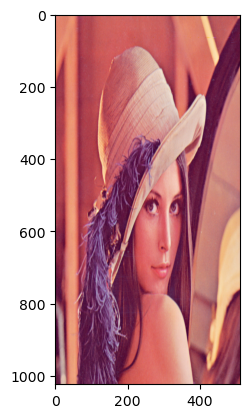

old image shape: (512, 512, 3) new image shape: (1024, 512, 3)


In [8]:
new_image = cv2.resize(image, None, fx=1, fy=2, interpolation=cv2.INTER_CUBIC)
# Thay đổi kích thước ảnh bằng OpenCV
# - fx=1 : giữ nguyên chiều ngang (width)
# - fy=2 : phóng to ảnh theo chiều dọc (height) gấp 2 lần
# - interpolation=cv2.INTER_CUBIC:
#   + Nội suy bicubic (bậc 3)
#   + Tạo ảnh mượt, giảm răng cưa khi phóng to

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
# Chuyển ảnh từ không gian màu BGR (OpenCV) sang RGB (matplotlib)
# Nếu không chuyển màu → ảnh hiển thị sai màu

plt.show() # Hiển thị ảnh ra màn hình

print("old image shape:", image.shape, "new image shape:", new_image.shape)
# In ra kích thước ảnh trước và sau khi resize
# shape có dạng: (height, width, channels)
# Ta sẽ thấy height tăng gấp đôi, width giữ nguyên

We can scale the horizontal axis and vertical axis by two.


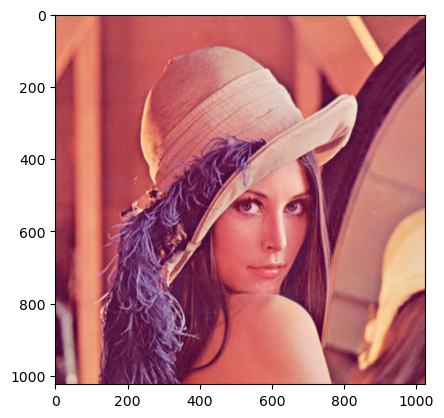

old image shape: (512, 512, 3) new image shape: (1024, 1024, 3)


In [9]:
new_image = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
# Thay đổi kích thước ảnh bằng OpenCV
# - fx=2 : phóng to ảnh theo chiều ngang gấp 2 lần
# - fy=2 : phóng to ảnh theo chiều dọc gấp 2 lần
# → Ảnh được phóng to đồng đều, giữ nguyên tỷ lệ gốc
# - interpolation=cv2.INTER_CUBIC:
#   + Nội suy bicubic (bậc 3)
#   + Chất lượng cao, ảnh mượt, ít răng cưa khi phóng to

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
# Chuyển ảnh từ không gian màu BGR sang RGB
# Để hiển thị đúng màu trong matplotlib

plt.show() # Hiển thị ảnh ra màn hình

print("old image shape:", image.shape, "new image shape:", new_image.shape)
# In ra kích thước ảnh trước và sau khi resize
# shape = (height, width, channels)
# Cả height và width đều tăng gấp đôi

We can also shrink the image by setting the scaling factor to a real number between 0 and 1:


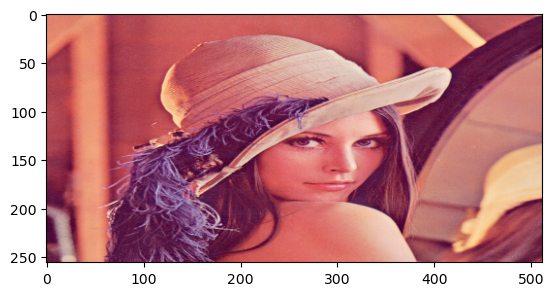

old image shape: (512, 512, 3) new image shape: (256, 512, 3)


In [10]:
new_image = cv2.resize(image, None, fx=1, fy=0.5, interpolation=cv2.INTER_CUBIC)
# Thay đổi kích thước ảnh bằng OpenCV
# - fx=1   : giữ nguyên chiều ngang (width)
# - fy=0.5 : thu nhỏ ảnh theo chiều dọc còn 1/2
# → Ảnh bị nén theo chiều cao
# - interpolation=cv2.INTER_CUBIC:
#   + Nội suy bicubic
#   + Tạo ảnh mượt, giảm răng cưa khi thay đổi kích thước

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)) # Chuyển ảnh từ BGR sang RGB để hiển thị đúng màu

plt.show() # Hiển thị ảnh ra màn hình

print("old image shape:", image.shape, "new image shape:", new_image.shape)
# In ra kích thước ảnh trước và sau khi resize
# shape = (height, width, channels)
# Chiều cao giảm còn một nửa, chiều ngang giữ nguyên

We can  also specify the number of rows and columns:


In [11]:
rows = 100 # Số hàng (chiều cao) của ảnh 

cols = 200 # Số cột (chiều rộng) của ảnh 

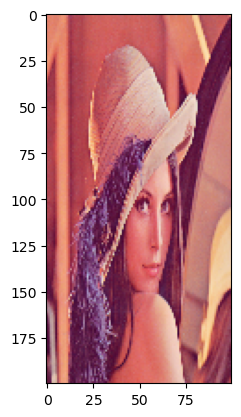

old image shape: (512, 512, 3) new image shape: (200, 100, 3)


In [12]:
new_image = cv2.resize(image, (100, 200), interpolation=cv2.INTER_CUBIC)
# Thay đổi kích thước ảnh bằng OpenCV theo kích thước cố định
# (100, 200) = (width, height)
# → Khác với fx, fy: ở đây ta chỉ định trực tiếp kích thước mong muốn
# - interpolation=cv2.INTER_CUBIC:
#   + Nội suy bicubic (bậc 3)
#   + Cho ảnh mượt, chất lượng cao khi thay đổi kích thước

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)) # Chuyển ảnh từ không gian màu BGR sang RGB để hiển thị đúng màu

plt.show() # Hiển thị ảnh ra màn hình

print("old image shape:", image.shape, "new image shape:", new_image.shape)
# In ra kích thước ảnh trước và sau khi resize
# image.shape = (height, width, channels)
# new_image.shape = (200, 100, channels)

## Translation


Translation is  when you  shift the location of the image. <code>tx</code> is the number of pixels you shift the location in the horizontal direction and <code>ty</code> is the number of pixels you shift in the vertical direction. You can create the transformation matrix $M$ to shift the image. 

In this example, we shift the image 100 pixels horizontally:


In [13]:
tx = 100
# Độ dịch chuyển theo trục x (chiều ngang)
# Ảnh sẽ được dời sang phải 100 pixel

ty = 0
# Độ dịch chuyển theo trục y (chiều dọc)
# ty = 0 nghĩa là không dịch lên/xuống

M = np.float32([[1, 0, tx],
                [0, 1, ty]])
# Tạo ma trận biến đổi affine 2x3 cho phép tịnh tiến ảnh
# Dạng tổng quát:
# [ 1  0  tx ]
# [ 0  1  ty ]
# → Giữ nguyên hình dạng, chỉ dịch chuyển vị trí ảnh

M # In ra ma trận tịnh tiến

array([[  1.,   0., 100.],
       [  0.,   1.,   0.]], dtype=float32)

The shape of the image is given by:


In [14]:
rows, cols, _ = image.shape
# Lấy kích thước của ảnh màu từ thuộc tính shape
# image.shape có dạng: (height, width, channels)
# rows  = height  (số hàng – chiều cao ảnh)
# cols  = width   (số cột – chiều rộng ảnh)
# _     = số kênh màu (thường là 3: BGR/RGB), gán vào _ vì không dùng

We use the function <code>warpAffine</code> from the <code>cv2</code> module. The first input parater is an image array, the second input parameter is the transformation matrix <code>M</code>, and the final input paramter is the length and width of the output image $(cols,rows)$:


In [15]:
new_image = cv2.warpAffine(image, M, (cols, rows))
# Áp dụng phép biến đổi affine (tịnh tiến) lên ảnh
# - image : ảnh gốc đầu vào
# - M     : ma trận affine 2x3 (ma trận tịnh tiến đã tạo ở trên)
# - (cols, rows) : kích thước ảnh đầu ra (width, height)
# Kết quả là ảnh mới đã được dịch chuyển theo tx, ty

We can plot the image; the portions of the image that do not have any intensities are set to zero:


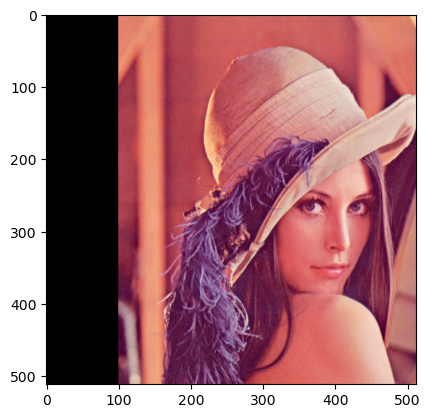

In [16]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
# Chuyển ảnh từ không gian màu BGR (OpenCV) sang RGB
# Để hiển thị đúng màu khi dùng matplotlib

plt.show() # Hiển thị ảnh sau khi áp dụng phép biến đổi (tịnh tiến)

We can see some of the original image has been cut off. We can fix this by changing the output image size: <code>(cols + tx,rows + ty)</code>:


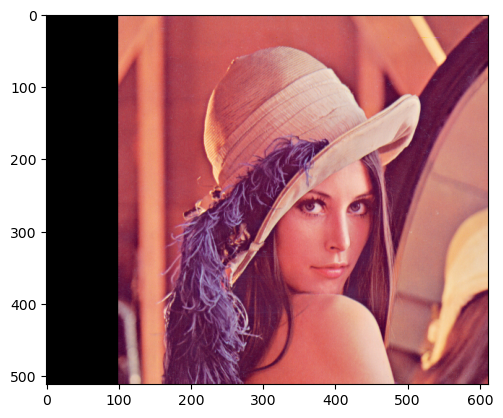

In [17]:
new_image = cv2.warpAffine(image, M, (cols + tx, rows + ty))
# Áp dụng phép biến đổi affine (tịnh tiến) lên ảnh
# - image : ảnh gốc
# - M     : ma trận tịnh tiến [[1, 0, tx], [0, 1, ty]]
# - (cols + tx, rows + ty):
#   + Mở rộng kích thước ảnh đầu ra
#   + Tránh việc ảnh bị cắt mất phần dịch chuyển
# Kết quả: ảnh được dời sang phải tx pixel và vẫn giữ toàn bộ nội dung

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)) # Chuyển ảnh từ BGR sang RGB để hiển thị đúng màu

plt.show() # Hiển thị ảnh ra màn hình

We can shift the image horizontally:


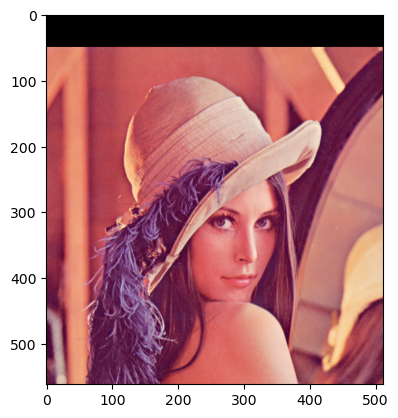

In [18]:
tx = 0
# Độ dịch chuyển theo trục x (chiều ngang)
# tx = 0 → ảnh không dịch sang trái/phải

ty = 50
# Độ dịch chuyển theo trục y (chiều dọc)
# ty = 50 → ảnh dịch xuống dưới 50 pixel

M = np.float32([[1, 0, tx],
                [0, 1, ty]])
# Ma trận biến đổi affine cho phép tịnh tiến ảnh
# Dạng:
# [1  0  tx]
# [0  1  ty]

new_iamge = cv2.warpAffine(image, M, (cols + tx, rows + ty))
# Áp dụng phép tịnh tiến lên ảnh
# - Ảnh được dời xuống dưới 50 pixel
# - Mở rộng khung ảnh để tránh bị cắt mất nội dung

plt.imshow(cv2.cvtColor(new_iamge, cv2.COLOR_BGR2RGB)) # Chuyển ảnh từ BGR sang RGB để hiển thị đúng màu

plt.show() # Hiển thị ảnh sau khi tịnh tiến

## Rotation 


We can rotate an image by angle θ which is achieved by the Rotation Matrix <code>getRotationMatrix2D</code>.


<p><code>center</code>: Center of the rotation in the source image. We will only use the center of the image.</p>
<p><code>angle</code>: Rotation angle in degrees. Positive values mean counter-clockwise rotation (the coordinate origin is assumed to be the top-left corner).</p>
<p><code>scale</code>: Isotropic scale factor, in this course the value will be one.</p>


We can rotate our toy image by 45 degrees:


In [19]:
theta = 45.0
# Góc xoay của ảnh (đơn vị: độ)
# Giá trị dương → xoay ngược chiều kim đồng hồ

M = cv2.getRotationMatrix2D(center=(3, 3), angle=theta, scale=1)
# Tạo ma trận xoay affine 2x3
# - center=(3, 3): tâm xoay (tọa độ pixel)
#   Với ảnh 6x6 → tâm gần giữa ảnh
# - angle=theta  : góc xoay (độ)
# - scale=1      : giữ nguyên kích thước (không phóng to/thu nhỏ)

new_toy_image = cv2.warpAffine(toy_image, M, (6, 6))
# Áp dụng phép xoay lên ảnh toy_image
# - Kích thước ảnh đầu ra là 6x6
# - Một số pixel có thể bị mất hoặc sinh vùng đen do xoay

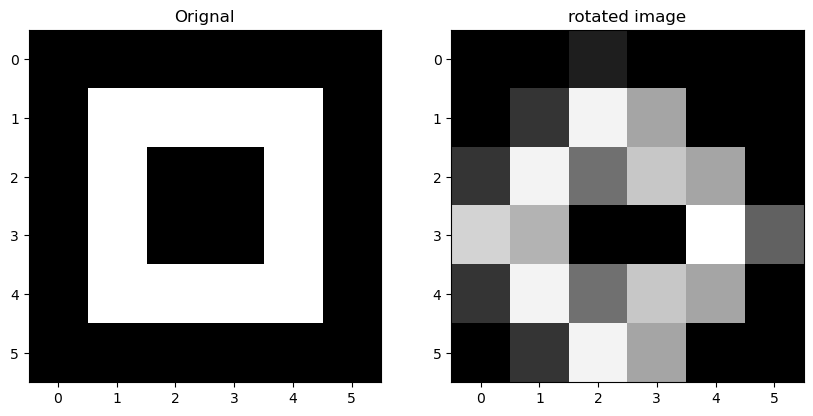

In [20]:
plot_image(toy_image, new_toy_image, title_1="Orignal", title_2="rotated image")
# Gọi hàm plot_image để hiển thị 2 ảnh song song
# - toy_image      : ảnh gốc ban đầu
# - new_toy_image  : ảnh sau khi xoay 45 độ
# - title_1        : tiêu đề ảnh gốc
# - title_2        : tiêu đề ảnh sau khi xoay

Looking at intensity values, we see that many values have been interpolated:


In [21]:
new_toy_image
# Ma trận numpy 2D chứa giá trị pixel của ảnh sau khi xoay 45 độ
# Kết quả được tạo ra bởi hàm cv2.warpAffine
# Kích thước vẫn là 6x6 như ảnh gốc
# Các pixel mới sinh ra (do xoay) có giá trị 0 => màu đen

array([[  0.        ,   0.        ,  28.38867188,   0.        ,
          0.        ,   0.        ],
       [  0.        ,  47.8125    , 223.125     , 151.40625   ,
          0.        ,   0.        ],
       [ 47.8125    , 223.125     , 103.59375   , 183.28125   ,
        151.40625   ,   0.        ],
       [195.234375  , 165.10253906,   0.        ,   0.        ,
        234.82910156,  89.89746094],
       [ 47.8125    , 223.125     , 103.59375   , 183.28125   ,
        151.40625   ,   0.        ],
       [  0.        ,  47.8125    , 223.125     , 151.40625   ,
          0.        ,   0.        ]])

We can perform the same operation on color images:


In [22]:
rows, cols, _ = image.shape   # rows: cao, cols: rộng, _: số kênh màu

In [23]:
M = cv2.getRotationMatrix2D(
    center=(cols // 2 - 1, rows // 2 - 1),  # Tọa độ tâm xoay: gần chính giữa ảnh
    angle=theta,                           # Góc xoay (độ), dương là ngược chiều kim đồng hồ
    scale=1                                # Tỉ lệ zoom (1 = giữ nguyên kích thước)
)

new_image = cv2.warpAffine(
    image,                                 # Ảnh gốc
    M,                                     # Ma trận affine (xoay + tịnh tiến)
    (cols, rows)                           # Kích thước ảnh đầu ra (rộng, cao)
)

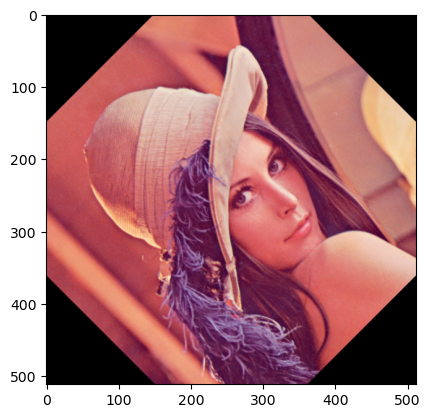

In [24]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)) # Chuyển ảnh từ hệ màu BGR (mặc định của OpenCV) sang hệ màu RGB để matplotlib hiển thị đúng màu

plt.show() # Hiển thị ảnh sau khi xoay (hoặc biến đổi affine)

# Mathematical Operations 


## Array Operations 


We can perform array operations on an image; Using Python broadcasting, we can add a constant to each pixel's intensity value. 


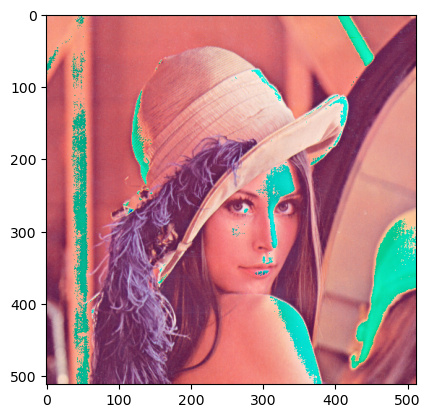

In [25]:
new_image = image + 20
# Tăng giá trị cường độ của mỗi pixel lên 20
# => Ảnh sáng hơn
# (Thao tác cộng trực tiếp trên mảng NumPy)

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)) # Chuyển ảnh từ BGR sang RGB để hiển thị đúng màu bằng matplotlib

plt.show() # Hiển thị ảnh sau khi tăng độ sáng

We can also multiply every pixel's intensity value by a constant value.


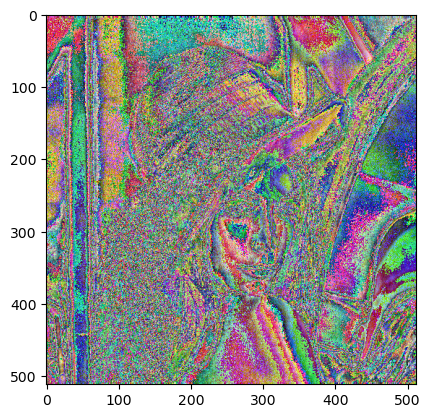

In [26]:
new_image = 10 * image
# Nhân mỗi giá trị pixel với 10
# => Tăng mạnh độ sáng và độ tương phản của ảnh
# => Rất dễ bị tràn giá trị (overflow) vì pixel vượt quá 255

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)) # Chuyển ảnh từ BGR sang RGB để matplotlib hiển thị đúng màu

plt.show() # Hiển thị ảnh sau khi nhân cường độ pixel

We can add the elements of two arrays of equal shape. In this example, we generate an array of random noises with the same shape and data type as our image.


In [28]:
Noise = np.random.normal(0, 20, (rows, cols, 3)).astype(np.uint8)
# Tạo nhiễu Gaussian (phân phối chuẩn)
# - Mean = 0        => nhiễu không làm sáng/tối tổng thể
# - Std = 20        => mức độ nhiễu (độ mạnh của nhiễu)
# - Kích thước (rows, cols, 3) → nhiễu cho ảnh màu 3 kênh (BGR)
# Chuyển kiểu dữ liệu sang uint8 để phù hợp với ảnh

Noise.shape
# Kiểm tra kích thước của ma trận nhiễu
# Đảm bảo noise có cùng kích thước với ảnh gốc

(512, 512, 3)

We add the generated noise to the image and plot the result. We see the values that have corrupted the image:


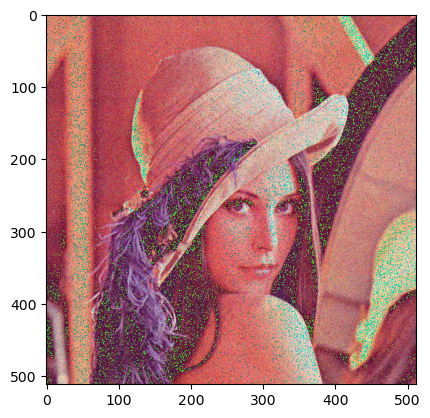

In [29]:
new_image = image + Noise
# Cộng nhiễu Gaussian vào ảnh gốc
# => Mỗi pixel bị thay đổi ngẫu nhiên
# => Ảnh xuất hiện hạt nhiễu (noise)
# Đây là phép cộng từng phần tử của hai mảng NumPy

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)) # Chuyển ảnh từ hệ màu BGR sang RGB để hiển thị đúng màu

plt.show() # Hiển thị ảnh sau khi thêm nhiễu

At the same time, we can multiply the elements of two arrays of equal shape. We can multiply the random image and the Lenna image and plot the result. 


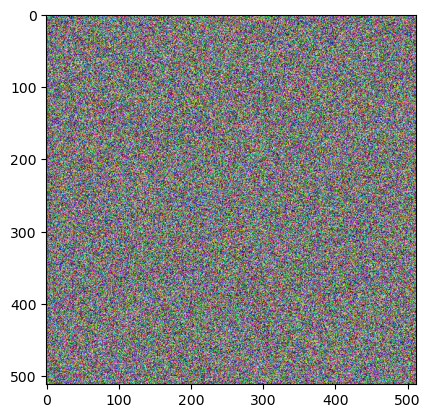

In [30]:
new_image = image * Noise
# Nhân ảnh với ma trận nhiễu
# => Tạo nhiễu nhân (multiplicative noise)
# => Pixel sáng bị ảnh hưởng mạnh hơn pixel tối
# => Làm biến dạng cường độ ảnh không đồng đều

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)) # Chuyển ảnh từ BGR sang RGB để hiển thị đúng màu bằng matplotlib

plt.show() # Hiển thị ảnh sau khi thêm nhiễu nhân

## Matrix Operations 


Grayscale images are matrices. Consider the following grayscale image:


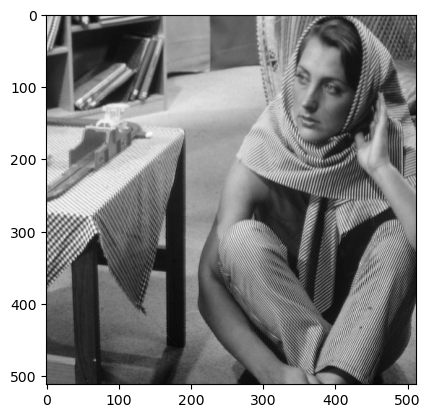

In [31]:
im_gray = cv2.imread('barbara.png', cv2.IMREAD_GRAYSCALE)
# Đọc ảnh 'barbara.png' ở chế độ ảnh xám (grayscale)
# => Mỗi pixel chỉ còn 1 giá trị cường độ sáng (0–255)
# => Kết quả là ảnh 2 chiều (rows, cols)

im_gray.shape
# Trả về kích thước ảnh xám
# (số hàng, số cột)

plt.imshow(im_gray, cmap='gray')
# Hiển thị ảnh xám bằng thang màu xám
# cmap='gray' để đảm bảo hiển thị đúng mức sáng

plt.show() # Hiển thị ảnh ra màn hình

We can apply algorithms designed for matrices.  We can use  Singular Value Decomposition, decomposing our image matrix into  a product of three matrices.


In [32]:
U, s, V = np.linalg.svd(im_gray, full_matrices=True)
# Thực hiện phân rã SVD (Singular Value Decomposition) trên ảnh xám
# im_gray = U · S · V
# U : ma trận trực giao chứa các vector riêng bên trái (hướng hàng)
# s : vector chứa các giá trị suy biến (singular values) theo thứ tự giảm dần
# V : ma trận trực giao chứa các vector riêng bên phải (hướng cột)
# full_matrices=True => tạo ma trận U và V có kích thước đầy đủ

We see <code>s</code> is not rectangular:


In [33]:
s.shape
# Trả về kích thước của vector s
# s chứa các singular values (giá trị suy biến)
# Số phần tử của s = min(số hàng, số cột của ảnh)

(512,)

We can convert  <code>s</code> to a diagonal matrix <code>S</code>:


In [34]:
S = np.zeros((im_gray.shape[0], im_gray.shape[1]))
# Tạo ma trận S kích thước bằng ảnh gốc
# Ban đầu tất cả phần tử đều bằng 0
# Ma trận S sẽ chứa các singular values trên đường chéo chính

S[:image.shape[0], :image.shape[0]] = np.diag(s)
# Đưa các singular values vào đường chéo của ma trận S
# np.diag(s) tạo ma trận đường chéo từ vector s

We can plot the matrix `U` and `V`:


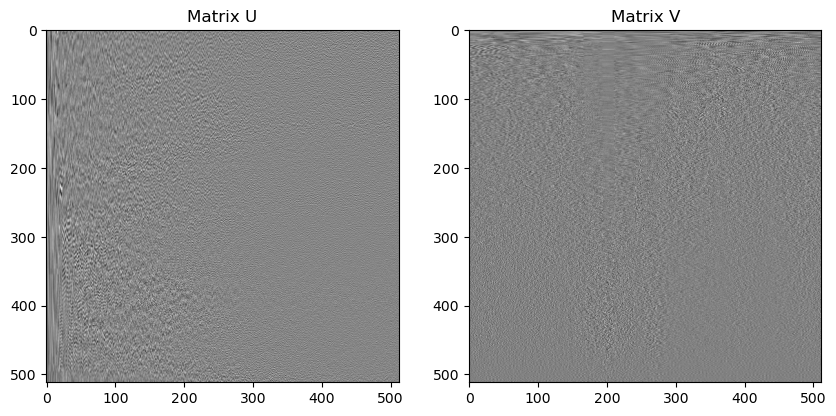

In [35]:
plot_image(U, V, title_1="Matrix U", title_2="Matrix V")
# Hiển thị ma trận U và V dưới dạng ảnh xám
# U: chứa các vector trực giao biểu diễn cấu trúc theo chiều hàng của ảnh
# V: chứa các vector trực giao biểu diễn cấu trúc theo chiều cột của ảnh
# Việc hiển thị giúp quan sát trực quan các mẫu (patterns) trong ảnh

We see most of the elements in `S` are zero:


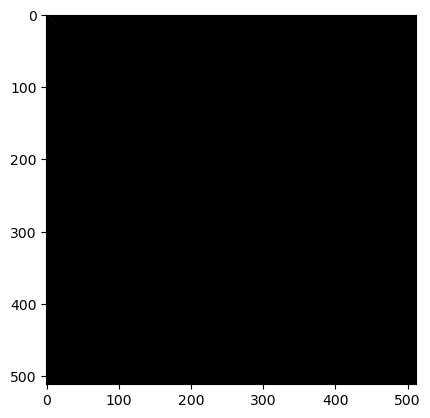

In [36]:
plt.imshow(S, cmap='gray')
# Hiển thị ma trận S dưới dạng ảnh xám
# Các giá trị khác 0 chỉ nằm trên đường chéo chính
# Mức sáng trên đường chéo biểu diễn độ lớn của singular values

plt.show() # Hiển thị hình ảnh ma trận S

We can find the matrix product of all the matrices. First, we can perform matrix multiplication on `S` and `U` and assign it  to `B` and plot the results: 


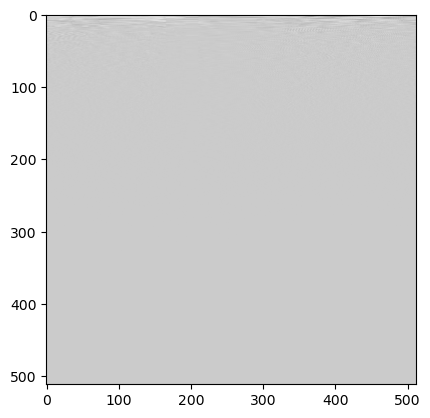

In [37]:
B = S.dot(V)
# Nhân ma trận S với ma trận V
# => Kết hợp năng lượng (S) với hướng đặc trưng theo chiều cột (V)
# => Đây là bước trung gian trong quá trình tái tạo ảnh

plt.imshow(B, cmap='gray')
# Hiển thị ma trận B dưới dạng ảnh xám
# Giúp quan sát kết quả sau khi nhân S và V

plt.show() # Hiển thị ảnh trung gian B

We can find the matrix product of `U`, `S`, and `B`. We see it’s the entire image:


In [38]:
A = U.dot(B)
# Nhân ma trận U với ma trận B (B = S · V)
# => Hoàn tất phép tái tạo ảnh: A = U · S · V
# => A là ảnh được tái tạo từ các thành phần SVD

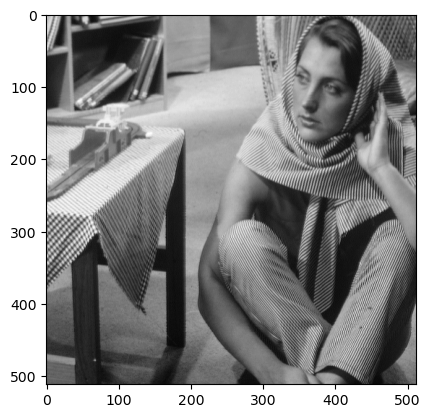

In [39]:
plt.imshow(A, cmap='gray')
# Hiển thị ảnh A (ảnh được tái tạo từ SVD)
# Sử dụng thang màu xám vì A là ảnh grayscale

plt.show() # Hiển thị ảnh ra màn hình

It turns out many elements are redundant, so we can eliminate some rows and columns of `S` and `V` and approximate the image by finding the product.


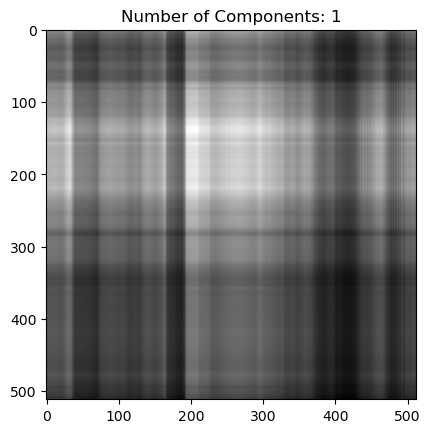

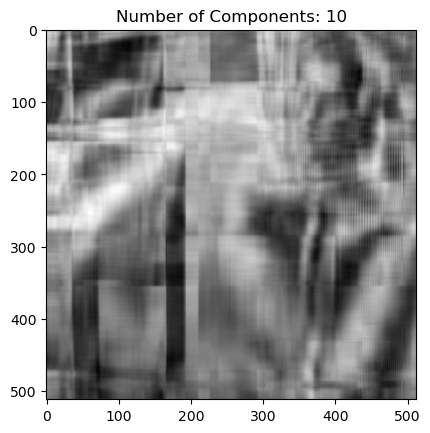

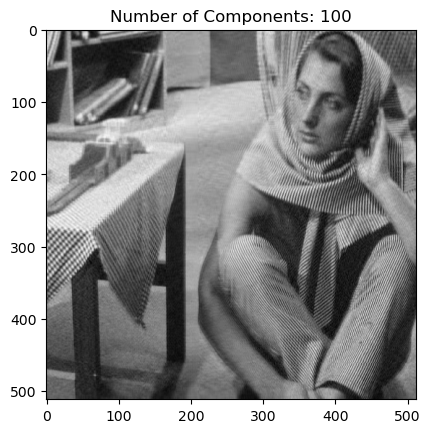

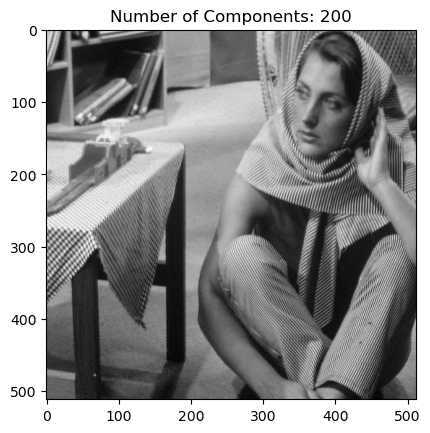

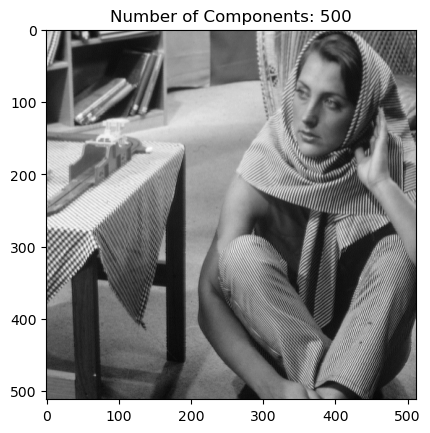

In [40]:
for n_component in [1, 10, 100, 200, 500]:
    # Lặp qua các số lượng singular values được giữ lại
    # Mỗi giá trị biểu diễn mức độ nén khác nhau

    S_new = S[:, :n_component]
    # Giữ lại n_component cột đầu tiên của ma trận S
    # => Chỉ sử dụng các singular values lớn nhất (quan trọng nhất)

    V_new = V[:n_component, :]
    # Giữ lại n_component hàng đầu tiên của ma trận V
    # => Tương ứng với các thành phần đã chọn trong S

    A = U.dot(S_new.dot(V_new))
    # Tái tạo ảnh bằng công thức SVD rút gọn
    # A ≈ U · S_new · V_new
    # => Ảnh xấp xỉ ảnh gốc

    plt.imshow(A, cmap='gray') # Hiển thị ảnh tái tạo với số thành phần hiện tại

    plt.title("Number of Components: " + str(n_component)) # Hiển thị số singular values được sử dụng

    plt.show() # Hiển thị kết quả

We see we only need 100 to 200 Components to represent the image.


# References 


[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.


<!--<h2>Change Log</h2>-->


<!--
<table>
    <tr>
        <th>Date (YYYY-MM-DD)</th>
        <th>Version</th>
        <th>Changed By</th>
        <th>Change Description</th>
    </tr>
    <tr>
        <td>2020-07-20</td>
        <td>0.2</td>
        <td>Azim</td>
        <td>Modified Multiple Areas</td>
    </tr>
    <tr>
        <td>2020-07-17</td>
        <td>0.1</td>
        <td>Azim</td>
        <td>Created Lab Template</td>
    </tr>
</table>
-->



<h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
